In [1]:
!pip install pandas
!pip install scipy

# Analisi correzione attiva del passo
## Tommaso Dani
### Obbiettivo: recuperare il segnale di correzione del passo sui tre assi (sbandamenti, accelerazioni e rimbalzi), confronto correzione con/senza scarpe.
### Collaboratori:
- Longo Debora: mi ha aiutato con l'idea sull'implementazione della funzione calcolo_soglia2, ovvero l'utilizzo della media dei picchi più alti e una percentuale negativa per ampliare l'effetto della sogliatura.

## Elementi di teoria
- Trasformata di Fourier e inversa <br>
  Nel raggiungimento dell'obbiettivo è necessario avere il concetto di trsformata di fourier e dell'inverso.
  La trasformata di Fourier permette di dividere il segnale nelle componenti delle frequenze, mentre per l'inverso date delle frequenze e le loro componenti posso ricostruire il segnale.
  
- Filtri passabasso e passabanda <br>
  I filtri passabasso e filtri passabanda sono necessari per l'analisi che ho costruito, i filtri passabasso (gaussiano, butterswort ...) vengono applicati nello spazio delle frequenze moltiplicando la funzione filtro (normalizzata a 1) alla FT del segnale da filtrare, i filtri passabanda lavorano similmente a quellipassabasso ma escludono anche frequenze alte.

  
- Filtri sul tempo e convoluzione
  I filtri sul tempo vengono applicati tramite convoluzione con una finestra di filtraggio nello spazio del tempo, nel mio caso utili per amplificare e ammorbidire il segnale delle correzioni.



### Specifiche teoria
- Trasformata di fourier: nello studio eseguito è necessaria per lavorare in modo più visuale sulle frequenze, e per separare il segnale in settori di frequenze (quelli su cui vengono cercati picchi oltre la media dei picchi più alti)
- IFT : serve a riportare un segnale nello spazio del tempo, utile nella costruizione del segnale sintetico delle correzioni (sottraggo il segnale della camminata 'ottimale' al segnale della camminata originale, la camminata ottimale è ottenuta dalla IFT delle componenti del segnale originale meno quello definito dai picchi, spiegato meglio sotto)
- I filtri passabasso e passabanda sono necessari per la costruizione dei segnali dei settori, il segnale originale viene filtrato nelle frequenze e ne vengono derivati i segnali dei settori di frequenze.
- I filtri sul tempo e la convoluzione sono stati utilizzati principalmente per ridurre/amplificare i punti in cui il segnale somiglia a un inpulso (ammorbidisco i picchi più acuti)

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
from IPython.display import display
from scipy import signal
import IPython
from scipy.signal import butter, filtfilt, lfilter
from scipy.ndimage import convolve1d
from scipy.signal import find_peaks, peak_widths

''' Path di ricerca dei contenuti del notebook '''
BASEPATH = "Data/"

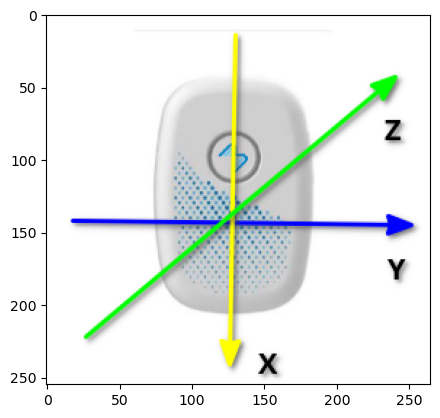

In [3]:
img = plt.imread(BASEPATH+'Axis.png')
plt.imshow(img)

## Osservazione dati
- I valori delle accelerazioni sono sommati ai valori delle gravità sugli assi
Per visualizzare meglio i risultati devo sottrarre la gravità alle accelerazioni
- Controllando i timestamp del sensore della caviglia posso trovare che la frequenza di campionamento è 50Hz

In [4]:
# @title
class signalArr:
    toll = 0.000001
    def __init__(self,a):
        self.a = a

    def normalize(self):
        #toll = 0.2
        filt = np.convolve(self.a, [-0.175, -0.175,-0.175, -0.175, 0, 0.175, 0.175, 0.175, 0.175])


        #recupero la media di shift della
        values = 0.
        nval = 0
        for i in range (np.size(self.a)):
            if (filt[i] < self.toll and filt[i] > -self.toll):
                values += self.a[i]
                nval += 1
        values /= nval

        a = np.zeros(np.size(self.a))
        #rimuovo lo shift
        for i in range (np.size(self.a)):
            a[i] = self.a[i] - values

        return signalArr(a)

    def normalize_2(self, campioni):
        acc = self.normalize()
        asum = 0
        pos = 0
        i = 0
        
        '''
        for ac in acc.a:
            
            asum += acb
            if (pos == campioni-1):
                y = i-pos
                for interval in acc.a[i-pos:i]:
                    acc.a[y] = interval - (asum / campioni)
                    y += 1
                    
                asum = 0
                pos = -1

                
            i += 1
            pos += 1
        '''
        for ac in acc.a:
            asum += ac

        for ac in acc.a:
            acc.a[i] -= asum / np.size(acc.a,0)
            i += 1



        for ac in acc.a:
            asum += ac
            i+=1

        t = i/50 #tempo totale
        vel = asum * t #velocità finale

        print (vel)
        
        return signalArr(acc.a)

    def normalize_3(self, campioni):
        acc = self.normalize()
        #acc = acc.normalize_2(campioni)
        i = 0
        pos = 0
        t = campioni / 50
        asum = 0
        
        
        for ac in acc.a:
            
            asum += ac
            if (pos == campioni-1):
                y = i-pos
                veltot = asum*t
                #veltot dev'essere pari a 0 per tenere fermo il sistema
                # 0 = asum*t - veltot 
                offacc = -veltot/t
                
                for interval in acc.a[i-pos:i]:
                    
                    
                    acc.a[y] = interval + (offacc / campioni)
                    y += 1
                    
                asum = 0
                pos = -1

                
            i += 1
            pos += 1

        acc = acc.normalize_2(campioni)
        
        for ac in acc.a:
            asum += ac
            i+=1

        t = i/50 #tempo totale
        vel = asum * t #velocità finale
        '''
        #ora devo trovare l'accelerazione negativa per quel tempo
        offacc = -vel / t

        for j in range(i):
            acc.a[j] += offacc/i
        '''
        print (vel)
        
        return signalArr(acc.a)
    
    def medfilt(self):
        return signalArr(signal.medfilt(self.a,kernel_size=None))


class sensor:
    def __init__(self, *args):

       if (len(args) == 1):
           a1,a2,a3,v1,v2,v3,g1,g2,g3,t = self.__separate_data(args[0])
           self.ax = signalArr(self.__remove_g(a1,g1))
           self.ay = signalArr(self.__remove_g(a2,g2))
           self.az = signalArr(self.__remove_g(a3,g3))
           self.vx = v1
           self.vy = v2
           self.vz = v3
           self.gx = g1
           self.gy = g2
           self.gz = g3
           self.time = self.__time_reset(t)
       else:
           self.ay = signalArr(np.copy(args[0]))
           self.ax = signalArr(np.copy(args[1]))
           self.az = signalArr(np.copy(args[2]))
           self.vx = np.copy(args[3].vx)
           self.vy = np.copy(args[3].vy)
           self.vz = np.copy(args[3].vz)
           self.gx = np.copy(args[3].gx)
           self.gy = np.copy(args[3].gy)
           self.gz = np.copy(args[3].gz)
           self.time = np.copy(args[3].time)

    def __remove_g (self, acc, g):
        return np.subtract(acc,g)

    def __separate_data (self, datapath):
        dataseg = pd.read_csv(datapath).to_numpy();
        arSz = np.size(dataseg,axis=0);
        ax = np.zeros(arSz)
        ay = np.zeros(arSz)
        az = np.zeros(arSz)

        vx = np.zeros(arSz)
        vy = np.zeros(arSz)
        vz = np.zeros(arSz)

        gx = np.zeros(arSz)
        gy = np.zeros(arSz)
        gz = np.zeros(arSz)

        time = np.zeros(arSz)

        for i in range (arSz):
            #separo velocità
            vx[i] = dataseg[i][1]
            vy[i] = dataseg[i][2]
            vz[i] = dataseg[i][3]
            #separo accelerazioni
            ax[i] = dataseg[i][4]
            ay[i] = dataseg[i][5]
            az[i] = dataseg[i][6]
            #separo garvità
            gx[i] = dataseg[i][7]
            gy[i] = dataseg[i][8]
            gz[i] = dataseg[i][9]
            #separo tempo
            time[i] = dataseg[i][0]

        return ax, ay, az, vx, vy, vz, gx, gy, gz, time

    def __time_reset(self,t):
        st = t[0]
        for i in range (np.size(t)):
            t[i] -= st
            t[i] /= 1000000000;
        return t

    def period(self):
        t = 0.
        prec = 0
        for i in self.time:
            t += (i - prec)
            prec = i
        t /= np.size(self.time, axis=0)
        return t

    def freq_arr(self,size):
        return np.fft.fftshift(np.fft.fftfreq(size,self.period()))

    def save_csv(self, name):
        # Creazione di un DataFrame pandas con i dati da salvare
        data = {
                'time': self.time,
                'vx': self.vx,
                'vy': self.vy,
                'vz': self.vz,
                'ax': self.ax.a, 
                'ay': self.ay.a,
                'az': self.az.a,
                'gx': self.gx,
                'gy': self.gy,
                'gz': self.gz
                }
        df = pd.DataFrame(data)
        # Salvataggio del DataFrame in un file CSV
        df.to_csv(name, index=False)

## Definizione funzioni utili
### Funzioni di flitraggio
- Sono presenti le funzioni:
  - filtro gaussiano
  - filtro passabasso di buttersworth
  - filtro passabanda di buttersworth <br>
  Queste funzioni applicano il filtro nello spazio delle frequenze e restituiscono il segnale filtrato.
### Funzioni di separazione automatica intervalli interessanti
- Queste funzioni non vengono utilizzate in questo ambito.
  Utili per approccio sulle frequenze, rilevatosi di scarsa comprensione del segnale.
### Funzioni di ricerca soglia e segnale di correzione
- Funzioni calcola_soglia -> calcola_soglia2 :
  - servono a calcolare una soglia per definire dei picchi nel segnale che possono essere considerati parte della correzione del passo
  - per essere applicata va passata la percentuale di scarto (nel caso calcola_soglia2, quello utilizzato in questo caso) es. -5% = 5% al di sotto della media dei picchi più alti
- Funzione correction_fun:
  - si occupa di costruire e filtrare il segnale derivato dalla sogliatura, per una questione di artefatti causati dai calcoli i risultati vengono normalizzati ai valori prima di applicare filtraggio
- Funzione segnale_senza_correzione
  - si occupa di costruire il segnale sintetico 'corretto' togliendo le frequenze derivate dalla funzione correction_fun, con intervalli di frequenze ampie aumenta l'errore

In [5]:
# @title
''' Funzioni filtro, aprire per dettagli '''

''' la funzione fft serve a restituire la fft di un segnale in un formato migliore per la visualizzazione '''
''' esegue fftshift per avere i valori centrati sull'array '''
def fft(arr):
    return np.fft.fftshift(np.fft.fft(arr))

''' la funzione gaussian restituisce una gaussiana dato un sigma e un numero di campioni '''
''' serve per applicare filtro su frequenze o eventualmente su tempo '''
def gaussian(sigma,n):
    x = np.linspace(-n//2,n//2, n)
    bump = np.exp(-x**2/(2.*sigma**2))

    bump /= bump[int(n/2)] # normalize the integral to 1
    return x, bump

''' la funzione butter_lowpass ha parametri cutoff (frequenza di taglio) e fs che è la freq di campionamento '''
''' restituisce una funzione filtro che è possibile utilizzare con filtfilt '''
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs #frequenza normalizzata per evitare aliasing
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

''' la funzione lowpass_filter ha parametri data(segnale da filtrare), cutoff(frequenza di taglio) e period(periodo di campionamento)'''
''' restituisce il segnale filtrato con butter_lowpass '''
def lowpass_filter(data, cutoff, period, order=5):
    fs = 1/period
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

''' la funzione butter_bandpass ha in più rispetto a butter_lowpass il parametro low_cutoff che taglia le frequenze sotto la frequenza passata'''
def butter_bandpass(low_cutoff, high_cutoff, fs, order=5):
    nyquist = 0.5 * fs
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    b, a = butter(order, [low, high], btype='band', analog=False)
    return b, a

''' la funzione ha in più rispetto a lowpass_filter il parametro high_cutoff (utilizzato dalla funzione sopra) '''
''' necessaria per segmentare il segnale in base a intervalli di frequenza (utilizzo nella funzione split_signals) '''
def bandpass_filter(data, low_cutoff, high_cutoff, period, order=5):
    fs = 1/period
    b, a = butter_bandpass(low_cutoff, high_cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y


In [6]:
# @title
''' FUNIONI RIGUARDANTI L'IDEA_1, aprire per dettagli'''

''' la funzione find_freq_intervals prende come parametri la FT di un segnale, '''
''' la dimensione dell'intervallo preso in considerazione e quanti hz di distacco tra un settore e un'altro '''
''' l'obbiettivo della funzione è di restituire automaticamente un array di intervalli in cui il modulo delle frequenze è maggiore rispetto ad un intorno '''
''' lavora normalizzando la FT a 5 (valore che ho trovato funzionare bene) e poi fa il quadrato dei singoli moduli, '''
''' in questo modo esalto i valori della FT più elevati tralasciando quelli più vicini allo 0 '''
''' poi faccio una convoluzione della FT modificata con una gaussiana, in questo modo ammorbidisco i picchi e ne aumento l'impatto per il calcolo successivo '''
''' dopo sfuttando la funzione di peak-detection e peak_width mi trovo degli intervalli su cui incidono i picchi '''
''' infine in base alla distanza degli intervalli li amplifico o li riduco per rispettare il parametro f_range '''
def find_freq_intervals(fs1_fft, dim, f_range = 1):
    maxVal = fs1_fft[0]
    for i in fs1_fft:
        if (maxVal < i):
            maxVal = i
    mulFact = 1/(maxVal*0.2) #normalizzo a 5 la fft

    mulArr = np.full(dim,mulFact)
    amplified_fft = np.multiply(fs1_fft,mulArr)
    amplified_fft = np.exp2(np.abs(amplified_fft)) #applico exp2 per amplificare i valori della fft normalizzata a 5 con modulo maggiore

    #faccio convoluzione con gaussiana sulla fft
    windowg = signal.windows.gaussian(7, std=2)
    amplified_fft = convolve1d(amplified_fft,windowg) #applico filtro gaussiano per ridurre il rumore e selezionare ulteriormente i picchi interessanti

    peaks, _ = find_peaks(amplified_fft, height=5.4)

    #fft_filtered
    plt.plot(time_peaks,amplified_fft)
    plt.plot(peaks, amplified_fft[peaks], "x")

    print(peaks[int(len(peaks)/2):])


    #costrisco array contente gli intervalli di selezione dei picchi
    st_peak = peak_widths(amplified_fft, peaks[int(len(peaks)/2):])[2]
    end_peak = peak_widths(amplified_fft, peaks[int(len(peaks)/2):])[3]
    st_peak_int = np.zeros(len(st_peak), dtype=int)
    end_peak_int =  np.zeros(len(end_peak), dtype=int)

    for i in range (len(st_peak)):
        st_peak_int[i] = int(st_peak[i])

    for i in range (len(end_peak)):
        end_peak_int[i] = int(end_peak[i])

    st_freq = fs1.freq_arr(dim)[st_peak_int]
    end_freq = fs1.freq_arr(dim)[end_peak_int]

    print(st_freq)
    print(end_freq)

    #recupero maxi intervalli di filtraggio ('aliasing')
    peak_segs = [[]]
    c_loop = 0
    for end in range (len(end_freq)):
        if (c_loop > 0):
            c_loop -= 1
            continue
        if (end != len(end_freq)):
            temp = [st_freq[end]]
            tempst = end_freq[end]
            for st in range(end + 1,len(st_freq)):
                if (st_freq[st] > (f_range + tempst)):
                    if (tempst != 0):
                        temp.append(end_freq[st-1])
                    else:
                        temp.append(end_freq[st])
                    break
                c_loop += 1
                tempst = end_freq[st]
            if (len(temp) < 2):
                temp.append(end_freq[end])
            peak_segs.append(temp)

    #np.delete(peak_segs,1,axis=0)
    print(peak_segs[1:])
    return peak_segs[1:]

''' la funzione plot_segs richiede come parametri gli intervalli di frequenze, il segnale originale, il campionamento, un array di frequenze e un array di secondi '''
''' l'obbiettivo della funzione è di stampare dei grafici che rappresentano il segnale originale all'interno degli intervalli freq_intls '''
def plot_segs (freq_intls, acc, period, freqs, time):
    nplot = np.size(freq_intls, axis=0)

    plt.figure(figsize=(5*nplot,8))

    signal_segs = [[]]

    p = 1
    for i in freq_intls:
        if (p == 1):
            int_band = lowpass_filter(acc, np.abs(i[1]), period, 5)
        else:
            int_band = bandpass_filter(acc, np.abs(i[0]), np.abs(i[1]), period, 5)

        fft_int_band = np.fft.fftshift(np.fft.fft(int_band))
        signal_segs.append(fft_int_band)
        plt.subplot(2,nplot,p)
        plt.plot(freqs, np.abs(fft_int_band))
        plt.subplot(2,nplot,p+nplot)
        plt.plot(time, int_band)
        p += 1

    return signal_segs[1:]

''' la funzioine normalize prende un array come parametro '''
''' puo servire per normalizzare un segnale a 1 (anche una FT, basta che sia un'array) '''
def normalize(sig):
    mul = 1/np.max(sig)
    mulArr = np.full(np.size(sig,axis = 0),mul)
    return np.multiply(sig,mulArr)

In [7]:
# @title
''' FUNZIONI RIGUARDANTI L'IDEA_2, aprire per dettagli '''

''' la funzione split_signals prende come parametri un segnale e un valore di taglio dei filtri '''
''' l'obbiettivo è di sezionare come per la funzione find_freq_intervals di dividere il segnale in intervalli di frequenze '''
''' a differenza di find_freq_intervals il numero di intervalli è fissato (in questo caso 3) '''
''' questa funzione serve a correction_fun per lavorare più efficacemente, aumentando il numero di intervalli si migliora la precisione '''
''' i valori delle frequenze di divisione sono stati scelti arbitrariamente in base all'osservazione della FT del segnale originale '''
def split_signals(acc, mod = 8):
    fs1_butter = lowpass_filter(acc, 1.5, fs1.period(), mod)
    fs1_band = bandpass_filter(acc, 1.6, 10, fs1.period(), mod)
    fs1_band2 = bandpass_filter(acc, 10.1, 24, fs1.period(), mod)

    fft_butter = np.fft.fftshift(np.fft.fft(fs1_butter))
    fft_band = np.fft.fftshift(np.fft.fft(fs1_band))
    fft_band2 = np.fft.fftshift(np.fft.fft(fs1_band2))

    return [fs1_butter, fs1_band, fs1_band2], [fft_butter, fft_band, fft_band2]

''' la funzione calcola_soglia prende come parametri un segnale e una percentuale di scostamento dalla deviazione standard '''
''' serve a calcolare automaticamente una soglia sulla parte positiva dei segnali considerando la media positiva e la percentuale di scostamento dalla deviazione standard '''
def calcola_soglia(arr, perc):
    #calcolo soglie in modo automatico
    med = 0.
    num = 0
    for i in arr:
        if (i > 0):
            med += i
            num += 1
    med /= num

    return ((perc*((np.std(arr)+0.21)**2)+100)*med/100)

''' la funzione calcola_soglia prende come parametri un segnale e una percentuale di scostamento dalla media dei picchi più alti '''
''' serve a calcolare automaticamente una soglia sulla parte positiva dei segnali considerando i maggiori picchi positivi e una percentuale di scostamento dalla media dei picchi '''
def calcola_soglia2(arr, perc):
    #calcolo soglie in modo automatico
    s = int(np.size(arr)/10)
    maxes = []
    for i in range (0 , np.size(arr), s):
        maxes.append(np.max(arr[i: i+s]))

    med = 0.
    num = 0
    for i in maxes:
        med += i
        num += 1
    med /= num

    return ((perc+100)*med/100)

''' la funzione correction_fun prende come parametri un segnale, un array di secondi e due percentuali di scostamento dalla soglia (pos/neg) '''
''' serve a restituire un segnale sintetico cosituito da i picchi che superano la soglia sia in positivo che in negativo '''
''' il segnale sintetico corrisponde alle singole correzioni su un intervallo di tempo '''
''' effettua convoluzione con una finestra gaussiana per ampliare il peso della correzione sul tempo, i valori applicati alla gaussiana sono stati trovati per tentativi '''
def correction_fun(sig, time, sup, inf):
    a = (sig> calcola_soglia2(sig, sup))
    b = (sig< - calcola_soglia2(-sig, inf))

    a = (sig*a) - calcola_soglia2(sig, sup)
    b = (sig*b) + calcola_soglia2(-sig, inf)

    for i in range(len(a)):
        if a[i]<0:
            a[i] = 0
    for i in range(len(b)):
        if b[i]>0:
            b[i] = 0

    #plt.plot(time, a+b)
    #plt.show()

    top_a = np.max(a)
    top_b = np.max(-b)

    windowg = signal.windows.gaussian(100, std=10)
    a = signal.convolve(a,windowg, mode='same' ,method='direct')
    b = signal.convolve(b,windowg, mode='same' ,method='direct')
    a = (a / np.max(a)) * top_a
    b = (b / np.max(-b)) * top_b

    return a+b

''' la funzione segnale_senza_correzione prende come parametro un segnale e due percentuali di distacco dalla soglia '''
''' serve a costruire un segnale sintetico che non contiene le correzioni rilevate, dovrebbe risultare più costante nel tempo rispetto all'originale '''
def segnale_senza_correzione(sig, inf, sup):
    corretto = np.zeros(np.size(sig, axis = 1 ), dtype = 'complex128')

    for int_band in sig:
        r = correction_fun(int_band, s1.time[st:end], inf, sup)
        res = (np.fft.fft(int_band)) - (np.fft.fft(r))
        corretto += np.fft.ifft(res)
    return corretto



## Costruzione sensori e caricamento dati

In [8]:
#sensori utilizzati
s1 = sensor(BASEPATH + "Subj1/Con_scarpe/imu_0_data_sync.csv")
s2 = sensor(BASEPATH + "Subj1/Con_scarpe/imu_1_data_sync.csv")

#intervallo di campioni da prendere in considerazione
st = 4000
end = 5500
#dimensione intervallo
dim = end - st

## Correzione dei segnali raw dei sensori
- Per migliorare la leggibilità di alcuni grafici delle accelerazioni ho calibrato il segnale in modo tale da trovare coerentemente accelerazioni = 0 (velocità costante) <br>
  Questo lo noto in particolar modo all'inizio della registrazione dove il soggetto è fermo ma i sensori rilevano piccole accelerazioni costanti diverse da 0

- Nel segnale viene anche applicato un filtro mediano per rimuovere eventuali picchi anomali derivanti da rumore dei sensori

Viene selezionato un intervallo per questioni di leggibilità.

DETTAGLI CALIBRAZIONE

L'esempio sotto mostra la differenza del segnale originale da quello calibrato.
Per trovare l'indice di scostamento ho trovato dei punti di costanza sul segnale con **np.convolve(filt, [-0.5, 0, 0.5 ])**. <br>
Questo servirà poi per il calcolo delle soglie per costriure il segnale sintetico.

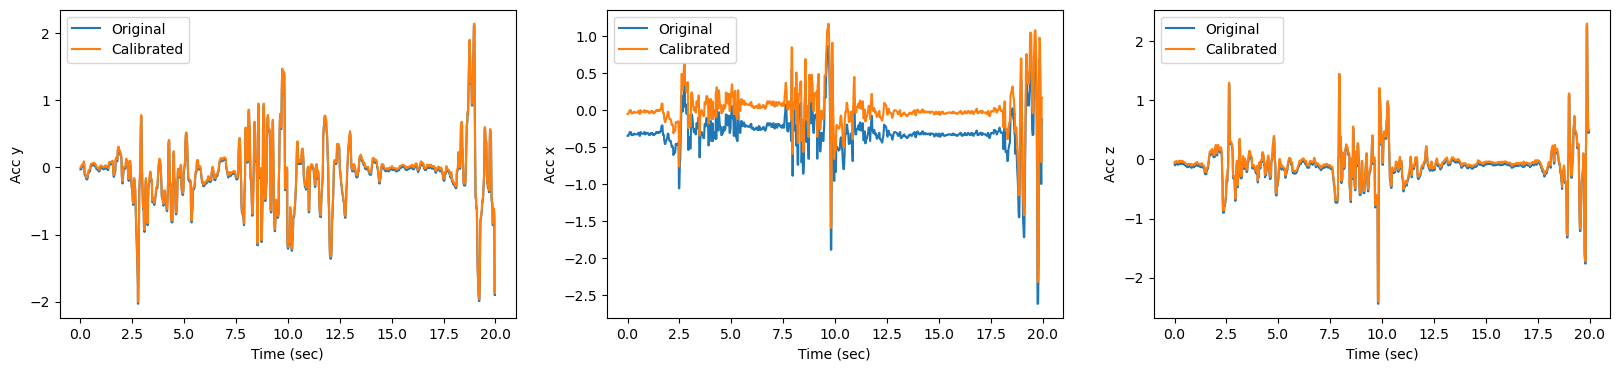

In [9]:
''' DETTAGLI CALIBRAZIONE (codice di visualizzazione) '''

#intervallo per esempio sotto
st_c = 0
end_c = 1000

plt.figure(figsize=(20,4))

plt.subplot(1,3,1)
plt.plot(s1.time[st_c:end_c], -s1.ay.medfilt().a[st_c:end_c])
plt.plot(s1.time[st_c:end_c], -s1.ay.normalize().medfilt().a[st_c:end_c])
plt.ylabel("Acc y")
plt.xlabel("Time (sec)")
plt.legend(["Original","Calibrated"])

plt.subplot(1,3,2)
plt.plot(s1.time[st_c:end_c], -s1.ax.medfilt().a[st_c:end_c])
plt.plot(s1.time[st_c:end_c], -s1.ax.normalize().medfilt().a[st_c:end_c])
plt.ylabel("Acc x")
plt.xlabel("Time (sec)")
plt.legend(["Original","Calibrated"])

plt.subplot(1,3,3)
plt.plot(s1.time[st_c:end_c], -s1.az.medfilt().a[st_c:end_c])
plt.plot(s1.time[st_c:end_c], -s1.az.normalize().medfilt().a[st_c:end_c])
plt.ylabel("Acc z")
plt.xlabel("Time (sec)")
plt.legend(["Original","Calibrated"])

## Prime considerazioni

- Considerato il segnale risultante posso ipotizzare che il sensore sulla gamba destra considera il segno dell'accelerazione opposta alla direzione della camminata.
  Per qeusto motivo rappresenterò il segnale con un segno - davanti
- Alla caviglia l'accelerazione ha prevalentemente un solo segno (su asse y), ciò significa che nella spinta non si ha grande accelerazione dato che il piede poggia a terra.


## FFT dei segnali calibrati
- Visualizzo le trasformate di Fourier per vedere se si può già notare qualcosa sulle correzioni guardando le frequenze

Text(0.5, 1.0, 'Fft Acc z')

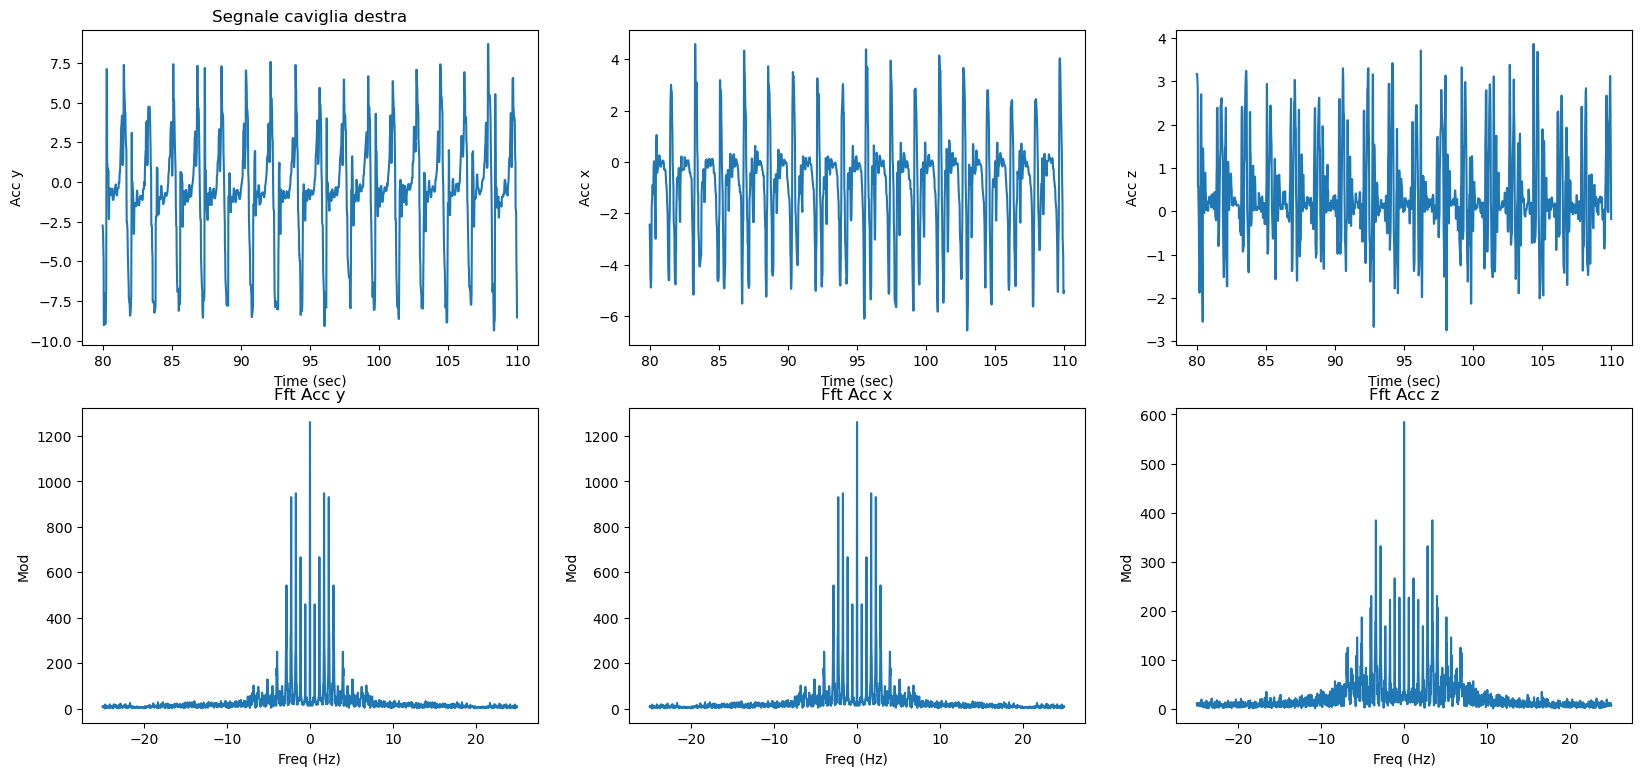

In [10]:
''' Grafici FFT segnali calibrati, aprire per dettagli '''

plt.figure(figsize=(20,9))

plt.subplot(2,3,1)
#plt.plot(s1.time[st:end], -s1.ay.normalize().medfilt().a[st:end])
plt.plot(s2.time[st:end], -s2.ay.normalize().medfilt().a[st:end])
plt.title("Segnale caviglia destra")
plt.ylabel("Acc y")
plt.xlabel("Time (sec)")
#plt.legend(["Coscia","Caviglia"])

plt.subplot(2,3,2)
#plt.plot(s1.time[st:end], -s1.ax.normalize().medfilt().a[st:end])
plt.plot(s2.time[st:end], -s2.ax.normalize().medfilt().a[st:end])
plt.ylabel("Acc x")
plt.xlabel("Time (sec)")
#plt.legend(["Coscia","Caviglia"])

plt.subplot(2,3,3)
#plt.plot(s1.time[st:end], -s1.az.normalize().medfilt().a[st:end])
plt.plot(s2.time[st:end], -s2.az.normalize().medfilt().a[st:end])
plt.ylabel("Acc z")
plt.xlabel("Time (sec)")
#plt.legend(["Coscia","Caviglia"])




plt.subplot(2,3,4)
#plt.plot(s1.freq_arr(dim), np.abs(fft(-s1.ax.medfilt().normalize().a[st:end])))
plt.plot(s2.freq_arr(dim), np.abs(fft(-s2.ax.medfilt().normalize().a[st:end])))
plt.ylabel("Mod")
plt.xlabel("Freq (Hz)")
#plt.legend(["Coscia","Caviglia"])
plt.title("Fft Acc y")

plt.subplot(2,3,5)
#plt.plot(s1.freq_arr(dim), np.abs(fft(-s1.ax.medfilt().normalize().a[st:end])))
plt.plot(s2.freq_arr(dim), np.abs(fft(-s2.ax.medfilt().normalize().a[st:end])))
plt.ylabel("Mod")
plt.xlabel("Freq (Hz)")
#plt.legend(["Coscia","Caviglia"])
plt.title("Fft Acc x")

plt.subplot(2,3,6)
#plt.plot(s1.freq_arr(dim), np.abs(fft(-s1.az.medfilt().normalize().a[st:end])))
plt.plot(s2.freq_arr(dim), np.abs(fft(-s2.az.medfilt().normalize().a[st:end])))
plt.ylabel("Mod")
plt.xlabel("Freq (Hz)")
#plt.legend(["Coscia","Caviglia"])
plt.title("Fft Acc z")

## Riduzione rumore di fondo
Devo ridurre il rumore di fondo dei sensori, per farlo posso lavorare sulle frequenze applicado un filtro gaussiano sulla fft

In [11]:
#creo una copia dei sensori con i filtri di base applicati

a1 = s1.ax.medfilt().normalize().a
a2 = s1.ay.medfilt().normalize().a
a3 = s1.az.medfilt().normalize().a
fs1 = sensor(a1,a2,a3,s1)

a1 = s2.ax.medfilt().normalize().a
a2 = s2.ay.medfilt().normalize().a
a3 = s2.az.medfilt().normalize().a
fs2 = sensor(a1,a2,a3,s2)

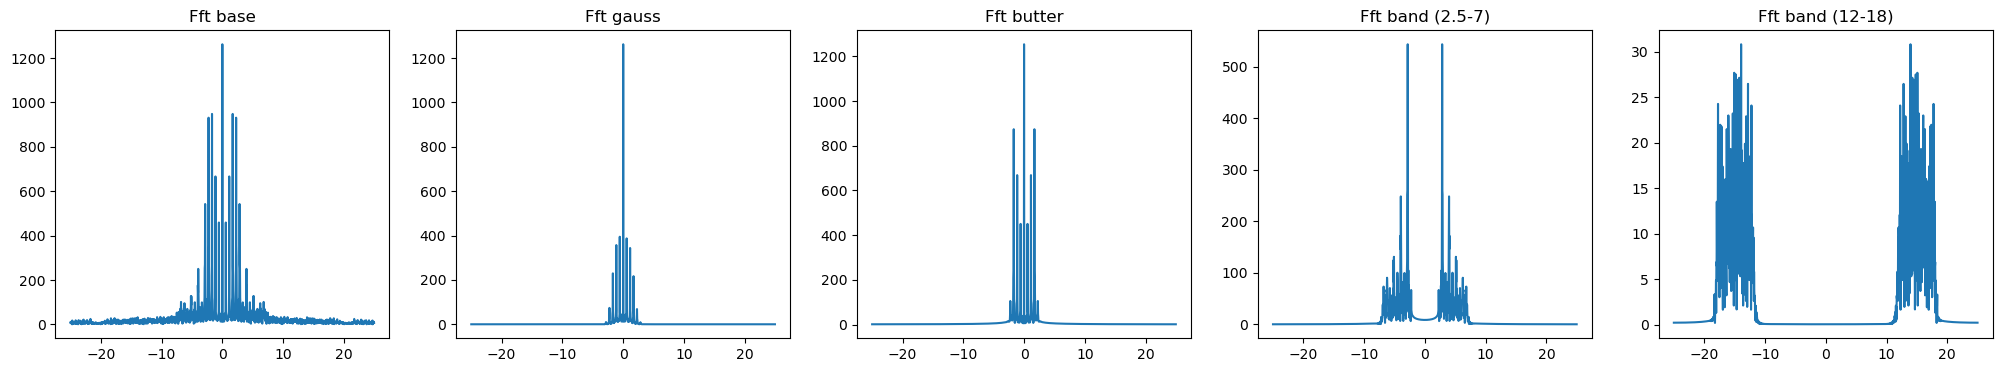

In [12]:
#definisco la gaussiana che uso da filtro
x,y = gaussian(30,dim)#(1/10*dim, dim)
y_shifted = np.fft.fftshift(y)
fft_gauss = np.fft.fft(y_shifted)

fs2_fft = fft(fs2.ay.a[st:end])
fft_gauss_n = np.multiply(y,fs2_fft)

fs2_butter = lowpass_filter(fs2.ay.a[st:end], 2, fs2.period(), 8)
fs2_band = bandpass_filter(fs2.ay.a[st:end], 2.5, 7, fs2.period(), 8)
fs2_band2 = bandpass_filter(fs2.ay.a[st:end], 12, 18, fs2.period(), 8)

fft_butter = np.fft.fftshift(np.fft.fft(fs2_butter))
fft_band = np.fft.fftshift(np.fft.fft(fs2_band))
fft_band2 = np.fft.fftshift(np.fft.fft(fs2_band2))

#plot dei risultati
plt.figure(figsize=(25,4))
plt.subplot(1,5,1)
plt.title("Fft base")
plt.plot(fs2.freq_arr(dim),np.abs(fs2_fft))
plt.subplot(1,5,2)
plt.title("Fft gauss")
plt.plot(fs2.freq_arr(dim),np.abs(fft_gauss_n))
plt.subplot(1,5,3)
plt.title("Fft butter")
plt.plot(fs2.freq_arr(dim), np.abs(fft_butter))
plt.subplot(1,5,4)
plt.title("Fft band (2.5-7)")
plt.plot(fs2.freq_arr(dim), np.abs(fft_band))
plt.subplot(1,5,5)
plt.title("Fft band (12-18)")
plt.plot(fs2.freq_arr(dim), np.abs(fft_band2))

## Considerazione filtri
Ho deciso di utilizzare un filtro di buttersworth dato che mi permette di avere un seganale filtrato con meno artefatti rispetto al filtro gaussiano.

## Come posso ricavare il segnale di correzione?
### Idea_1:
- Posso filtrare la abs.fft con un medfilt e recuperare gli intervalli in modo automatico controllando i peaks
- moltiplico la fft per un fattore di amplificazione in modo da avere una visione più pulita dei picchi
 - utilizzo un fattore moltiplicativo esponenziale in modo tale da ridurre i picchi di bassa entità
### Idea_2:
- Invece di lavorare sulle frequenze mi concentro sul segnale originale.
- Osservando il segnale posso notare che c'è una componente costante ma che sono presenti dei picchi dove l'accelerazione si scosta di molto dalla componente costante
- Ricavo la componente costante eliminando il segnale costruito separando i picchi più alti
- Ricavo il segnale di correzione sottraendo al segnale originale la componente costante


Procedo con l'idea_2 -> per lavorare sui picchi più alti divido il segnale in settori di freq e lavoro parallelamente sui settori


In [13]:
''' La funzione split_signal divide il segnali in settori di freq, dichiarata sotto funzioni utili '''

fs1_freqx, fs1_dftsx = split_signals(fs1.ax.a[st:end])
fs2_freqx, fs2_dftsx = split_signals(fs2.ax.a[st:end])
fs1_freqy, fs1_dftsy = split_signals(fs1.ay.a[st:end])
fs2_freqy, fs2_dftsy = split_signals(fs2.ay.a[st:end])
fs1_freqz, fs1_dftsz = split_signals(fs1.az.a[st:end])
fs2_freqz, fs2_dftsz = split_signals(fs2.az.a[st:end])


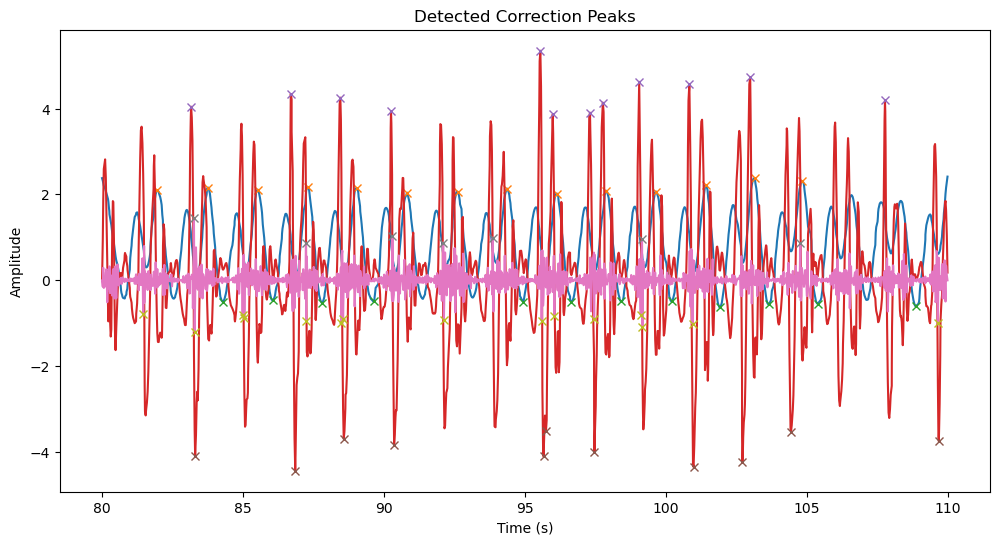

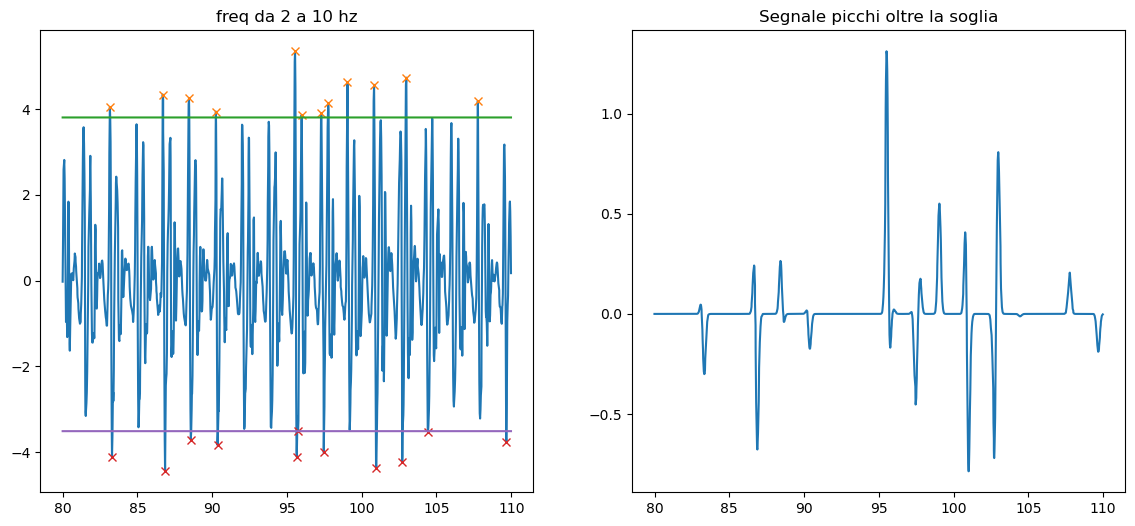

In [14]:
# @title
corretto_cav_y = np.zeros(dim, dtype = 'complex128')
perc_rim = -10

plt.figure(figsize=(12, 6))
for int_band in fs2_freqy:
    peaks, _ = find_peaks(int_band, height=calcola_soglia2(int_band, perc_rim))
    plt.plot(fs1.time[st:end], int_band)
    plt.plot(fs1.time[st:end][peaks], int_band[peaks], "x")
    peaks, _ = find_peaks(-int_band, height=calcola_soglia2(-int_band, perc_rim))
    plt.plot(fs1.time[st:end][peaks], int_band[peaks], "x")

    r = correction_fun(int_band, fs1.time[st:end], perc_rim, perc_rim)
    res = (np.fft.fft(int_band)) - (np.fft.fft(r))
    corretto_cav_y += np.fft.ifft(res)


plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Detected Correction Peaks')
plt.show()

corretto_cav_x = segnale_senza_correzione(fs2_freqx, perc_rim, perc_rim)
corretto_cav_z = segnale_senza_correzione(fs2_freqz, perc_rim, perc_rim)


#riscrittura correction_fun per esempio calcolo segnale sintetico di correzione su intervallo di freq
int_band = fs2_freqy[1]
a = (int_band> calcola_soglia2(int_band, perc_rim))
b = (int_band< - calcola_soglia2(-int_band, perc_rim))

a = (int_band*a) - calcola_soglia2(int_band, perc_rim)
b = (int_band*b) + calcola_soglia2(-int_band, perc_rim)

for i in range(len(a)):
    if a[i]<0:
        a[i] = 0
for i in range(len(b)):
    if b[i]>0:
        b[i] = 0

top_a = np.max(a)
top_b = np.max(-b)

windowg = signal.windows.gaussian(100, std=5)
a = signal.convolve(a,windowg, mode='same' ,method='direct')
b = signal.convolve(b,windowg, mode='same' ,method='direct')
a = (a / np.max(a)) * top_a
b = (b / np.max(-b)) * top_b

''' Mostro nello specifico caso sulle freq da 2 a 10 hz '''
plt.figure(figsize=(14, 6))

plt.subplot(1,2,1)
t = np.full(dim, calcola_soglia2(fs2_freqy[1], perc_rim))
peaks, _ = find_peaks(fs2_freqy[1], height=calcola_soglia2(fs2_freqy[1], perc_rim))
plt.plot(fs1.time[st:end], fs2_freqy[1])
plt.plot(fs1.time[st:end][peaks], fs2_freqy[1][peaks], "x")
plt.plot(fs1.time[st:end], t)
t = np.full(dim, calcola_soglia2(-fs2_freqy[1], perc_rim))
peaks, _ = find_peaks(-fs2_freqy[1], height=calcola_soglia2(-fs2_freqy[1], perc_rim))
plt.plot(fs1.time[st:end][peaks], fs2_freqy[1][peaks], "x")
plt.plot(fs1.time[st:end], -t)
plt.title('freq da 2 a 10 hz')

plt.subplot(1,2,2)
plt.plot(fs1.time[st:end], a+b)
plt.title('Segnale picchi oltre la soglia')
plt.show()

DATI INUTILI, dettagli sperimentazione

'''
per fs1_dfts[ 0 ] -> high = 2.6  std / 0.3 / convolve 1.75
                  -> low  = 0.69 std / 0.6 / convolve 1.75
per fs1_dfts[ 1 ] -> high = 2.56  std / 0.3
                  -> low  = 1.9 std / 0.6
'''

valori che ho trovato manualmente per le soglie (con utilizzo funzione calcolo_soglia1, poco ripetibile quindi scartata)


### Sogliatura
- Ho ricavato la soglia facendo una media dei picchi massimi, prima dividendo l'intervallo preso in considerazione in 10 sotto-intervalli
- Si può aumentare o diminuire la soglia percentualmente rispetto alla media trovata (considerata il 100%).


/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


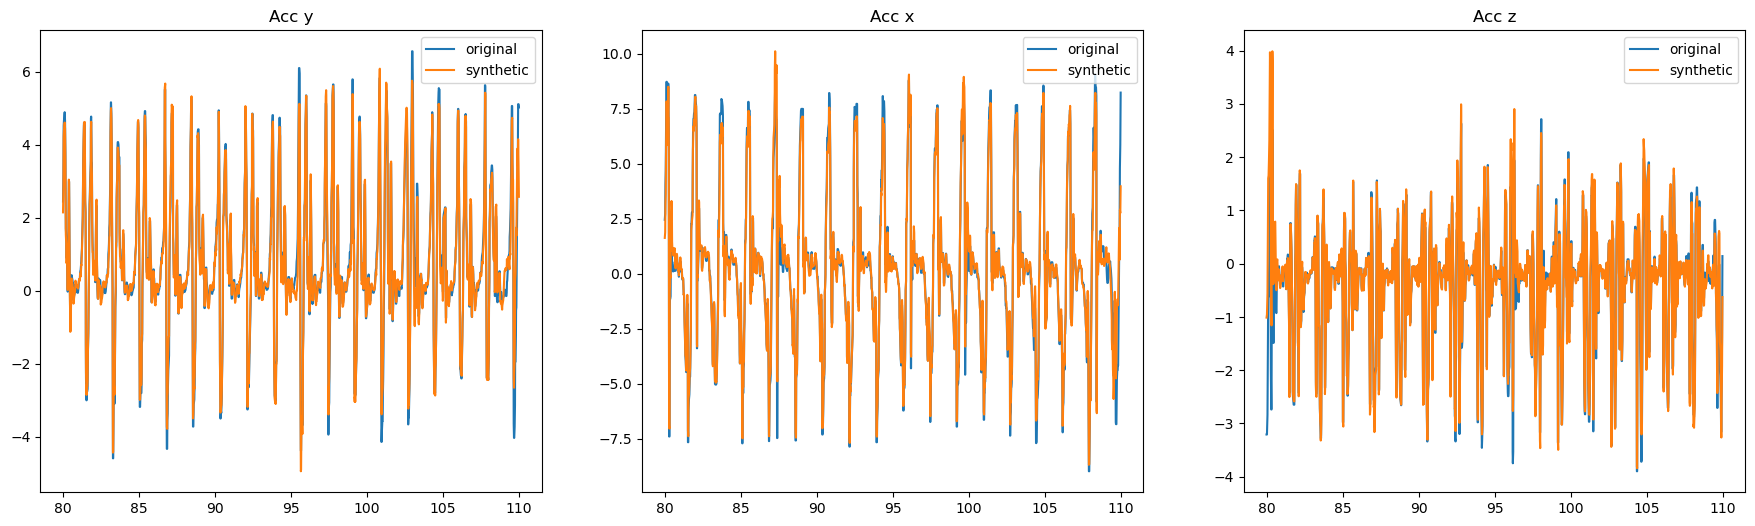

In [15]:
# @title
'''
per fs1_dfts[ 0 ] -> high = 2.6  std / 0.3 / convolve 1.75
                  -> low  = 0.69 std / 0.6 / convolve 1.75
per fs1_dfts[ 1 ] -> high = 2.56  std / 0.3
                  -> low  = 1.9 std / 0.6
'''
plt.figure(figsize=(22, 6))
plt.subplot(1,3,1)
plt.plot(fs1.time[st:end],fs2.ay.a[st:end])
plt.plot(fs1.time[st:end],corretto_cav_y)
plt.legend(['original','synthetic'])
plt.title('Acc y')
plt.subplot(1,3,2)
plt.plot(fs1.time[st:end],fs2.ax.a[st:end])
plt.plot(fs1.time[st:end],corretto_cav_x)
plt.legend(['original','synthetic'])
plt.title('Acc x')
plt.subplot(1,3,3)
plt.plot(fs1.time[st:end],fs2.az.a[st:end])
plt.plot(fs1.time[st:end],corretto_cav_z)
plt.legend(['original','synthetic'])
plt.title('Acc z')
plt.show()
#plt.plot(fs1.time[st:end],fs2.ay.a[st:end])

I grafici sopra rappresentano il segnale sintetico generato sottraendo al segnale originale le componenti delle frequenze che rappresentano i picchi oltre il valore di soglia. <br>
Da quello che si può notare che il segnale 'portante', ovvero quello più costante nel tempo, ha moduli a volte molto inferiori rispetto al segnale originale, questo è dovuto alla dimensione degli intervalli di frequenze che prendo in considerazione. <br>
Aumentando il numero di intervalli presi in considerazione posso diminuire l'errore sul calcolo.

## Segnale di Correzione
- Il segnale di correzione lo posso ricavare togliendo il segnale senza correzioni al segnale di base

Nel seguente esperimento mostro il segnale di correzione ricavato seguendo i passaggi dell'idea_2, questo dimostra che è possibile ricavare un segnale di correzione dal segnale originale.

In [16]:
corrz_x = fs2.ax.a[st:end]-corretto_cav_x
corrz_y = fs2.ay.a[st:end]-corretto_cav_y
corrz_z = fs2.az.a[st:end]-corretto_cav_z

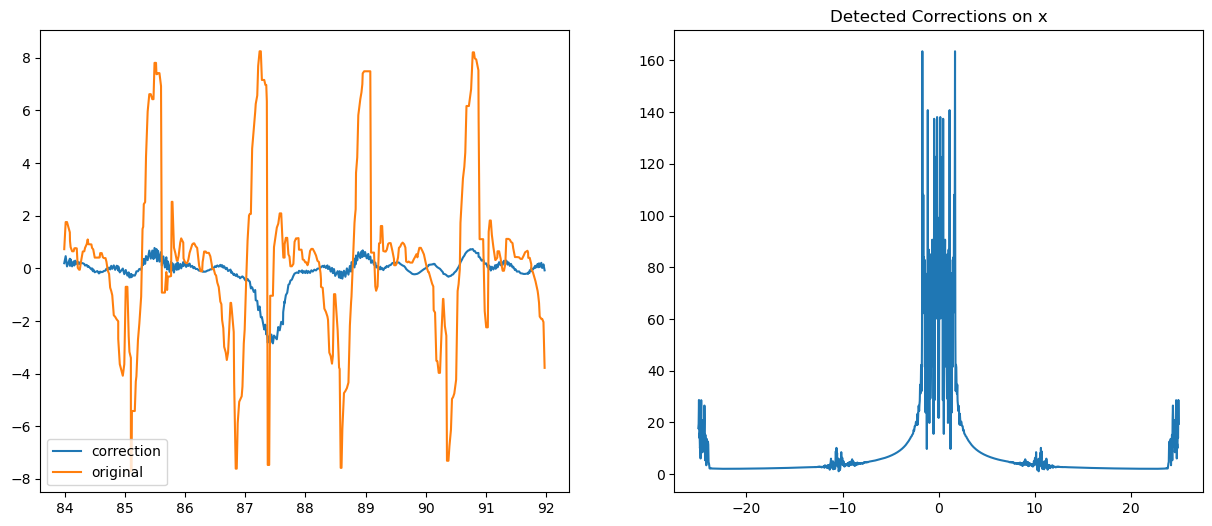

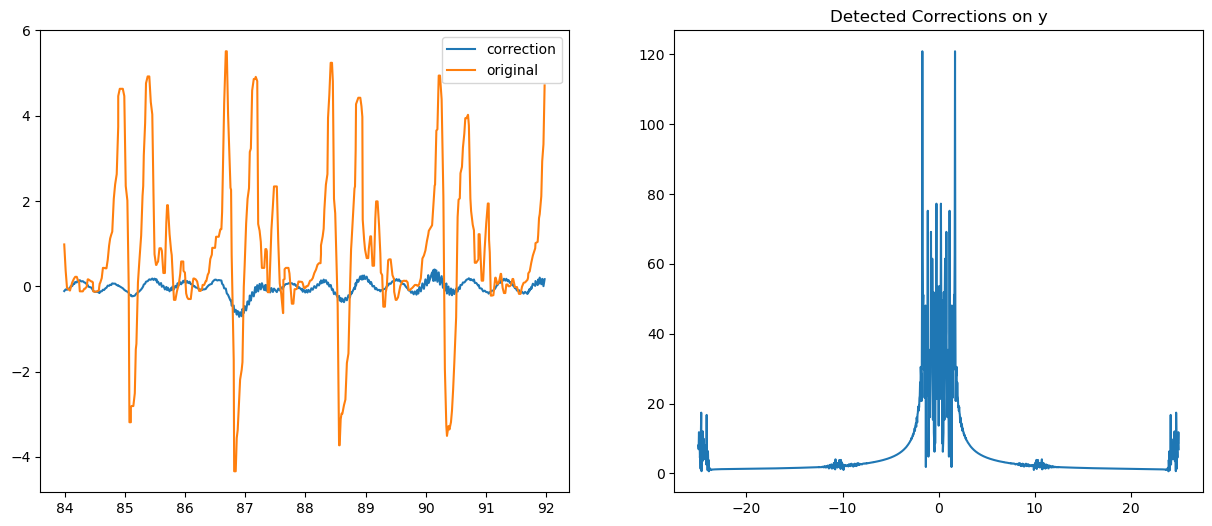

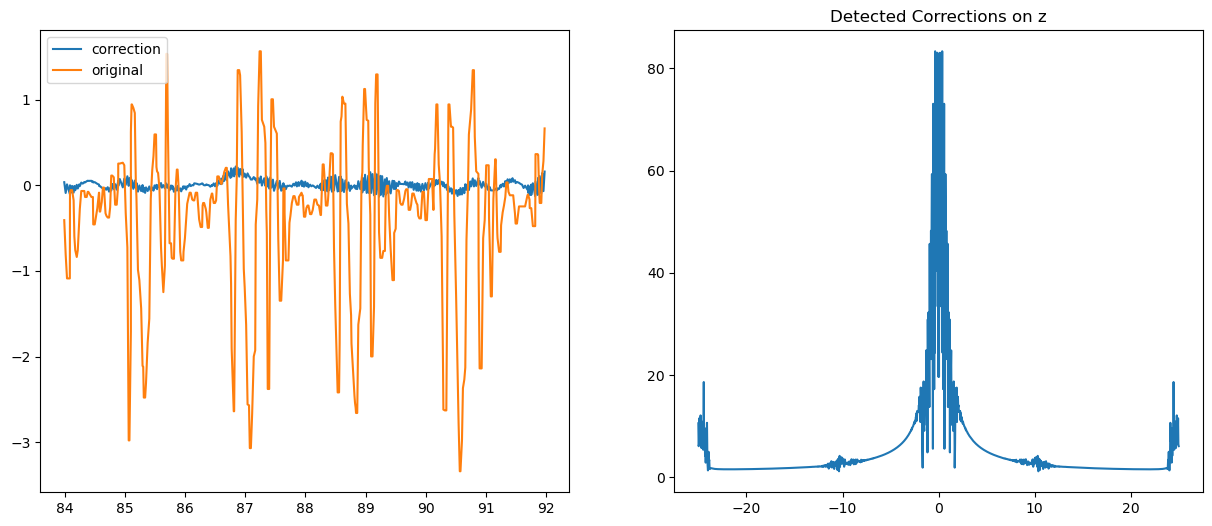

In [17]:
# @title
zoom_st = 200
zoom_end = 600

plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_x[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],fs2.ax.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_x))))
plt.title('Detected Corrections on x')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_y[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],fs2.ay.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_y))))
plt.title('Detected Corrections on y')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_z[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],fs2.az.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_z))))
plt.title('Detected Corrections on z')
plt.show()
#plt.plot(fs1.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(fs2.ay.a[st:end]))))


### Lettura dei grafici (DETTAGLI)
I grafici di sinistra sopra mostrano il segnale della correzione sui tre assi (in blu) e il segnale originale (in arancio) con a fianco il grafico della FT del segnale di correzione.

Da questi si può vedere come l'entità delle correzioni sia molto piccola rispetto al segnale di partenza, quindi in generale la camminata sull'intervallo preso in considerazione è di base piuttosto costante nel tempo.

Osservando la FT si può vedere che le frequenze che definiscono il segnale di correzione si trovano principalmente sotto la frequenza del periodo del passo, ciò significa che le correzioni sono presenti con un periodo minore rispetto al periodo del passo (le correzioni più importanti non avvengono ad ogni passo ma ogni n periodi).

Le altre frequenze che vengono in risalto nella FT si trovano nell'intervallo 8-12hz e >23hz;
Quelle del primo intervallo possono essere una componente del segnale di correzione che definisce gli spostamenti più intensi, dove è presente un cambio di velocità/direzione repentino in un piccolo intervallo di tempo, presenta comunque errore derivato dalla divisione delle frequenze dato che viene utilizzato un filtro arrotondato (possibile aliasing).
Quelle del secondo intervallo sono si componente delle correzioni ma comprendono buona parte del rumore dei sensori, quindi è possibile che alcune componenti della correzione si trovano fuori dalle frequenze rilevabili con l'intervallo di campionamento del sensore utilizzato (quindi frequenze > (fcampinamento/2)+1)



## Confronto (con/senza scarpe)
Eseguo il confronto tra il segnale di correzione sugli assi della camminata con scarpe con la camminata senza scarpe

In [18]:
# @title
''' Eseguo i passaggi per restituire il segnale di correzione da un nuovo sensore '''

s3 = sensor(BASEPATH + "Subj1/Senza_scarpe/imu_1_data_sync.csv") #caviglia senza scarpe
a1 = s3.ax.medfilt().normalize().a
a2 = s3.ay.medfilt().normalize().a
a3 = s3.az.medfilt().normalize().a
fs3 = sensor(a1,a2,a3,s3)
fs3_freqx, fs3_dftsx = split_signals(fs3.ax.a[st:end])
fs3_freqy, fs3_dftsy = split_signals(fs3.ay.a[st:end])
fs3_freqz, fs3_dftsz = split_signals(fs3.az.a[st:end])

corretto_cav_y = segnale_senza_correzione(fs3_freqy, perc_rim, perc_rim)
corretto_cav_x = segnale_senza_correzione(fs3_freqx, perc_rim, perc_rim)
corretto_cav_z = segnale_senza_correzione(fs3_freqz, perc_rim, perc_rim)

corrzNs_x = fs3.ax.a[st:end]-corretto_cav_x
corrzNs_y = fs3.ay.a[st:end]-corretto_cav_y
corrzNs_z = fs3.az.a[st:end]-corretto_cav_z

/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


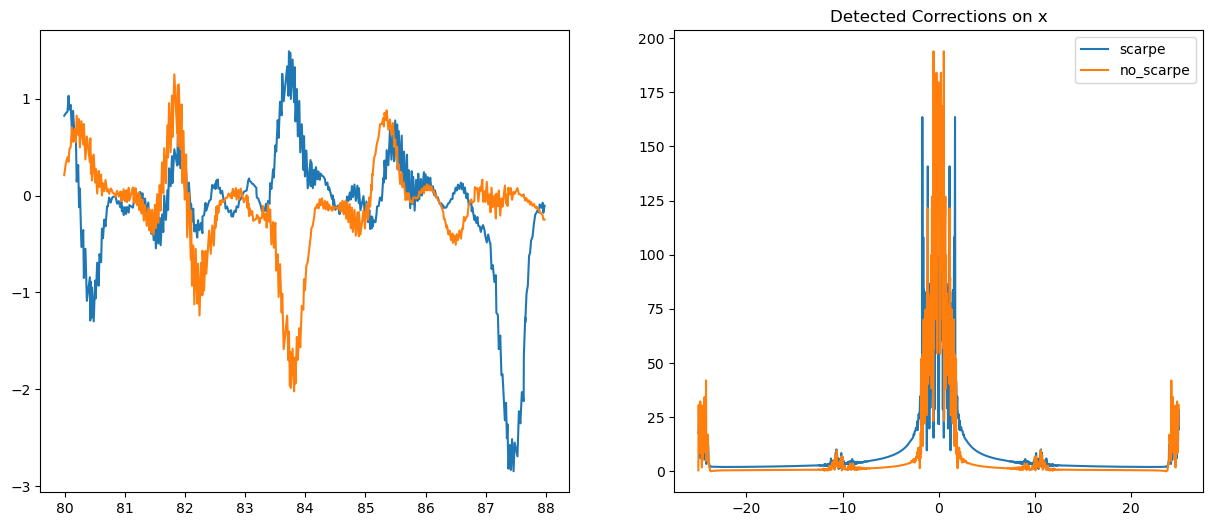

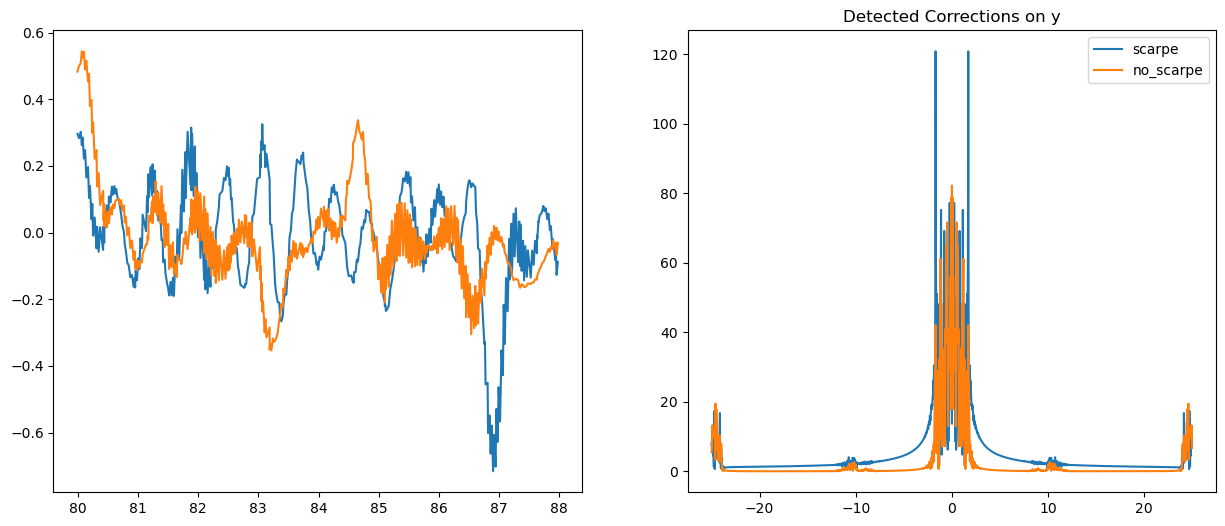

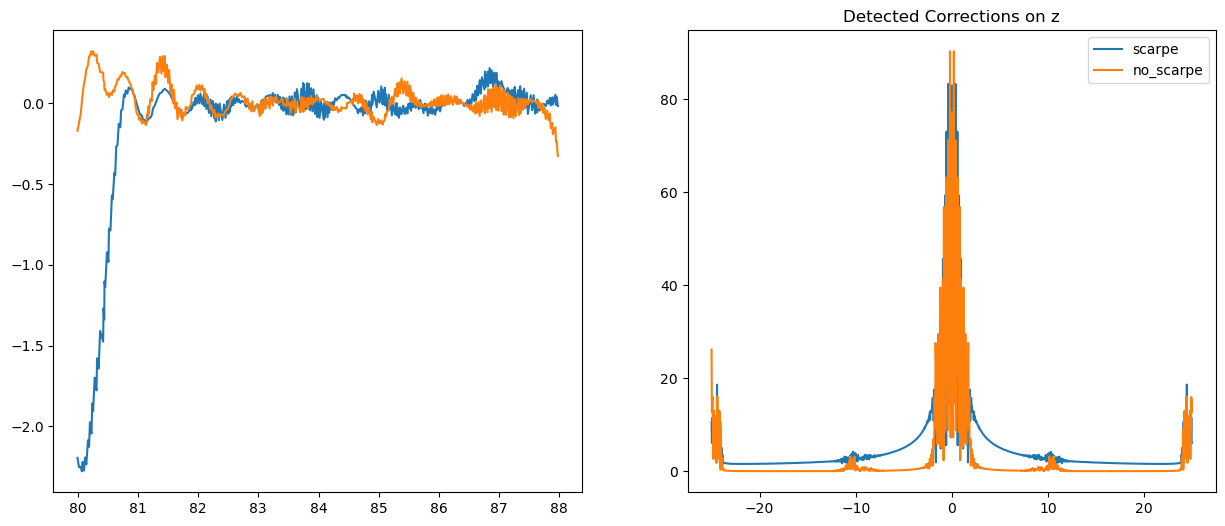

In [19]:
# @title
zoom_st = 0
zoom_end = 400

plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_x[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_x[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_x))))
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_x))))
plt.legend(['scarpe','no_scarpe'])
plt.title('Detected Corrections on x')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_y[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_y[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_y))))
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_y))))
plt.legend(['scarpe','no_scarpe'])
plt.title('Detected Corrections on y')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrz_z[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_z[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_z))))
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_z))))
plt.legend(['scarpe','no_scarpe'])
plt.title('Detected Corrections on z')
plt.show()

## Osservazioni del confronto
### Differenza scarpe / no scarpe:
- In generale la camminata senza scarpe possiede delle correzioni di modulo inferiore rispetto alla camminata con scarpe
- Differenza su assi:
  - Su asse y e x:
      - Considerando le fft dei segnali di correzione posso notare che le frequenze sul segnale di correzione sono simili
      - I moduli dell'intensità delle frequenze sia su asse y che su asse x sono inferiori nel caso senza scarpe rispetto al caso con le scarpe, ciò significa che (con i dati a disposizione) senza scarpe la camminata risulta più costante con correzioni di entità inferiore (falcate più costanti, alzate più precise).
      - Si possono notare delle differenze di segno nelle correzioni rispetto alle due camminate, questo può derivare dall'abitudine del soggetto a camminare con o senza scarpe, ovvero l'antiipazione del movimento della gamba necessita di una correzione in cui la direzione dipende da una sovrastima/sottostima dello spostamento
  - Su asse z:
      - Non sono presenti notevoli differenze tra le due camminate, la correzione sembra essere indipendente dall'uso o meno di scarpe
- Differenza di periodo:
  - La camminata senza scarpe risulta avere un periodo leggermente più breve rispetto alla camminata con scarpe (la velocità per essere più semplice la visualizzazione dei dai è la stessa in entrabe le camminate)

## Conclusioni
### Cosa ho imparato
- Dividere il segnale in intervalli di frequenze tramite filtraggio
- Scegliere lambda di filtraggio in base al segnale da filtrare
- calibrare il segnale tramite osservazione della derivata del segnale
### Cosa non ha funzionato
- Osservare la presenza delle correzioni attraverso la FT, essendo di entità molto inferiore rispetto alla FT del segnale di base risulta infattibile notarne le componenti dal grafico
- Lavorare esclusivamente nello spazio delle frequenze, rischio di aggiungere artefatti è elevato e comprometterebbe la visualizzazione

## Fonti e citazioni
Sono state effettuate letture generali sul sistema del passo.
L'idea che sta alla base di questo lavoro non si basa su ricerche effettuate da altri istituti ma è puramente personale, quindi contestabile.

Domande rivolte all'IA :
'A quali frequenze posso definire una correzione sul passo?' <br>
'Come si utilizza la funzione butter di scipy?'

# Esperimenti sulla generalità dei metodi
## Esperimento_1:
Il blocco di codice che segue è dedicato alla sperimentazione su un sensore a scelta.
### Variabili modificabili:
- PATH_SENSORE -> path di ricerca del sensore su cui fare l'analisi
- st -> seleziona l'inizio dell'intervallo su cui fare l'analisi (richiede l'indice dell'array ovvero la riga del file csv)
- end -> seleziona la fine dell'intervallo su cui fare l'analisi
- zoom_st -> seleziona l'indice da cui far partire uno zoom sull'intervallo definito da st-end (0 per partire da st o numero a scelta < end)
- zoom_end -> seleziona l'indice da cui far terminare lo zoom

In [20]:
PATH_SENSORE = "Subj1/Senza_scarpe/imu_1_data_sync.csv"
st = 1000 #inizio intervallo di ricerca
end = 2000 #fine intervallo di ricerca

zoom_st = 200
zoom_end = 600


In [21]:
# @title
dim = end - st
sensore = sensor(BASEPATH + PATH_SENSORE)

a1 = sensore.ax.medfilt().normalize().a
a2 = sensore.ay.medfilt().normalize().a
a3 = sensore.az.medfilt().normalize().a
sensoreFiltrato = sensor(a1,a2,a3,sensore)

sensoreFiltrato_x, sensoreFiltrato_ftx = split_signals(sensoreFiltrato.ax.a[st:end])
sensoreFiltrato_y, sensoreFiltrato_fty = split_signals(sensoreFiltrato.ay.a[st:end])
sensoreFiltrato_z, sensoreFiltrato_ftz = split_signals(sensoreFiltrato.az.a[st:end])

corretto_y = segnale_senza_correzione(sensoreFiltrato_y, perc_rim, perc_rim)
corretto_x = segnale_senza_correzione(sensoreFiltrato_x, perc_rim, perc_rim)
corretto_z = segnale_senza_correzione(sensoreFiltrato_z, perc_rim, perc_rim)

corrzNs_x = sensoreFiltrato.ax.a[st:end]-corretto_x
corrzNs_y = sensoreFiltrato.ay.a[st:end]-corretto_y
corrzNs_z = sensoreFiltrato.az.a[st:end]-corretto_z

/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


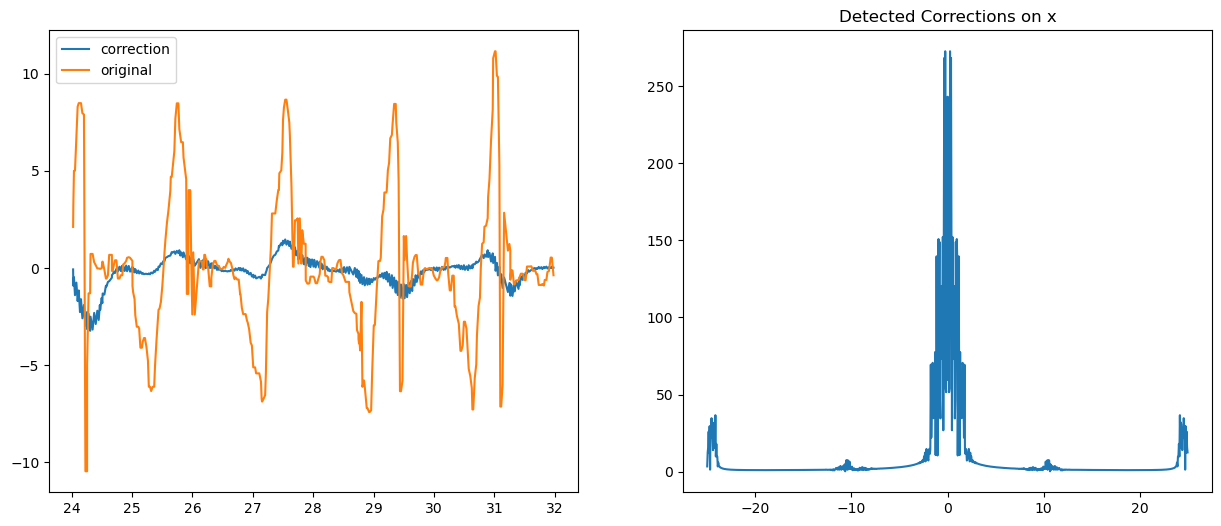

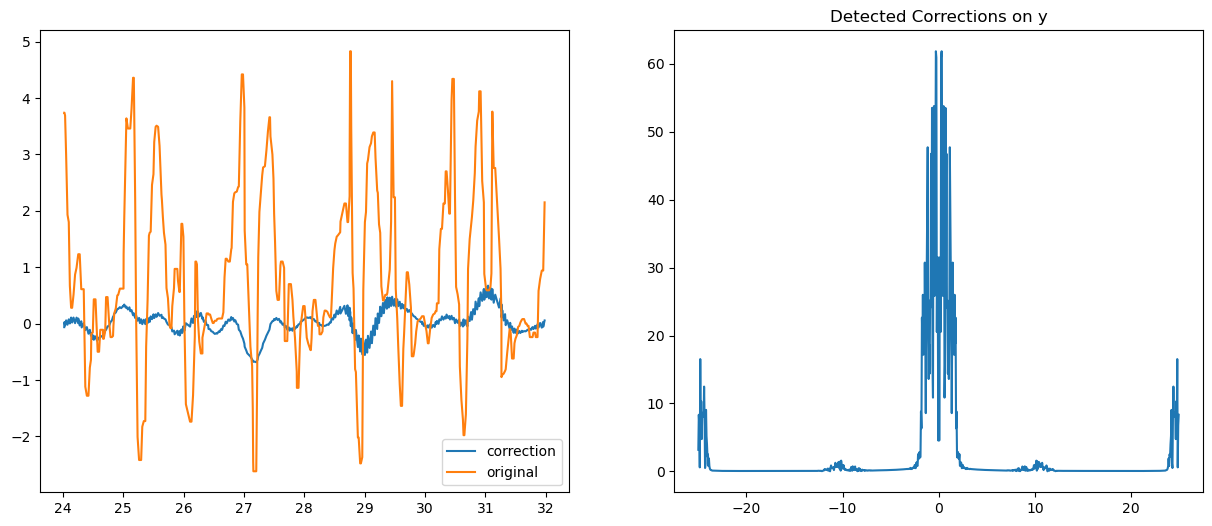

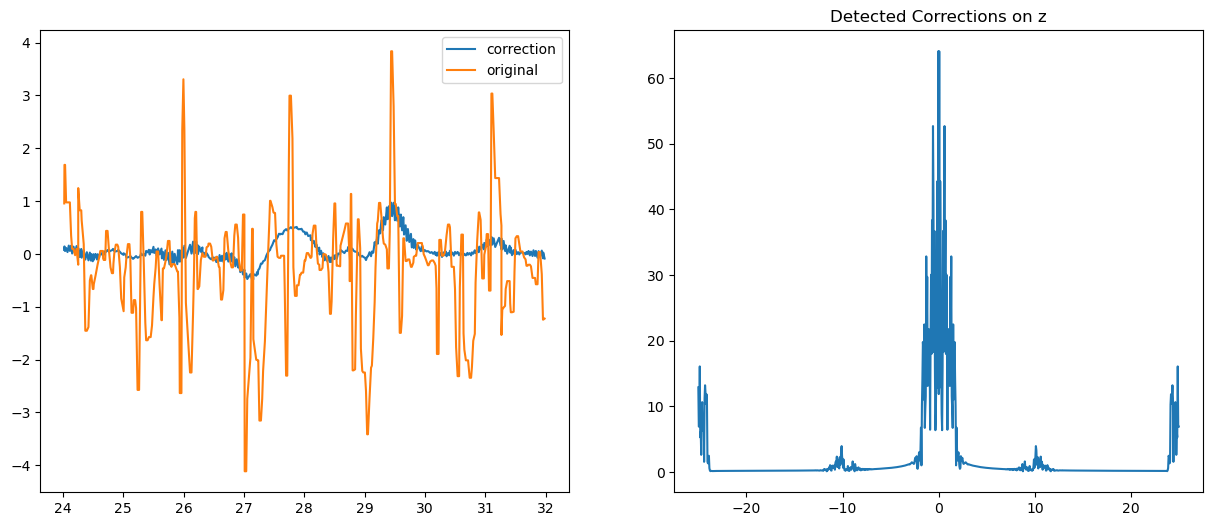

In [22]:
# @title
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_x[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],sensoreFiltrato.ax.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_x))))
plt.title('Detected Corrections on x')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_y[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],sensoreFiltrato.ay.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_y))))
plt.title('Detected Corrections on y')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(fs2.time[st+zoom_st:st+zoom_end],corrzNs_z[zoom_st:zoom_end])
plt.plot(fs2.time[st+zoom_st:st+zoom_end],sensoreFiltrato.az.a[st+zoom_st:st+zoom_end])
plt.legend(['correction','original'])
plt.subplot(1,2,2)
plt.plot(fs2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrzNs_z))))
plt.title('Detected Corrections on z')
plt.show()


## Esperimento_2:
Il blocco di codice che segue è dedicato alla sperimentazione su due sensori a scelta per essere confrontati.
### Variabili modificabili:
- PATH_SENSORE1 -> path di ricerca del primo sensore su cui fare l'analisi
- PATH_SENSORE2 -> path di ricerca del secondo sensore su cui fare l'analisi
- st -> seleziona l'inizio dell'intervallo su cui fare l'analisi (richiede l'indice dell'array ovvero la riga del file csv)
- end -> seleziona la fine dell'intervallo su cui fare l'analisi
- zoom_st -> seleziona l'indice da cui far partire uno zoom sull'intervallo definito da st-end (0 per partire da st o numero a scelta < end)
- zoom_end -> seleziona l'indice da cui far terminare lo zoom

In [23]:
PATH_SENSORE1 = "Subj1/Senza_scarpe/imu_1_data_sync.csv"
PATH_SENSORE2 = "Subj1/Con_scarpe/imu_1_data_sync.csv"
st = 1000 #inizio intervallo di ricerca
end = 2000 #fine intervallo di ricerca

zoom_st = 200
zoom_end = 600

In [24]:
# @title
dim = end - st
sensore1 = sensor(BASEPATH + PATH_SENSORE1)
sensore2 = sensor(BASEPATH + PATH_SENSORE2)

a1 = sensore1.ax.medfilt().normalize().a
a2 = sensore1.ay.medfilt().normalize().a
a3 = sensore1.az.medfilt().normalize().a
sensoreFiltrato1 = sensor(a1,a2,a3,sensore1)

a1 = sensore2.ax.medfilt().normalize().a
a2 = sensore2.ay.medfilt().normalize().a
a3 = sensore2.az.medfilt().normalize().a
sensoreFiltrato2 = sensor(a1,a2,a3,sensore2)

sensoreFiltrato1_x, sensoreFiltrato1_ftx = split_signals(sensoreFiltrato1.ax.a[st:end])
sensoreFiltrato1_y, sensoreFiltrato1_fty = split_signals(sensoreFiltrato1.ay.a[st:end])
sensoreFiltrato1_z, sensoreFiltrato1_ftz = split_signals(sensoreFiltrato1.az.a[st:end])
sensoreFiltrato2_x, sensoreFiltrato2_ftx = split_signals(sensoreFiltrato2.ax.a[st:end])
sensoreFiltrato2_y, sensoreFiltrato2_fty = split_signals(sensoreFiltrato2.ay.a[st:end])
sensoreFiltrato2_z, sensoreFiltrato2_ftz = split_signals(sensoreFiltrato2.az.a[st:end])

corretto_1_y = segnale_senza_correzione(sensoreFiltrato1_y, perc_rim, perc_rim)
corretto_1_x = segnale_senza_correzione(sensoreFiltrato1_x, perc_rim, perc_rim)
corretto_1_z = segnale_senza_correzione(sensoreFiltrato1_z, perc_rim, perc_rim)
corretto_2_y = segnale_senza_correzione(sensoreFiltrato2_y, perc_rim, perc_rim)
corretto_2_x = segnale_senza_correzione(sensoreFiltrato2_x, perc_rim, perc_rim)
corretto_2_z = segnale_senza_correzione(sensoreFiltrato2_z, perc_rim, perc_rim)

corrz_1_x = sensoreFiltrato1.ax.a[st:end]-corretto_1_x
corrz_1_y = sensoreFiltrato1.ay.a[st:end]-corretto_1_y
corrz_1_z = sensoreFiltrato1.az.a[st:end]-corretto_1_z
corrz_2_x = sensoreFiltrato2.ax.a[st:end]-corretto_2_x
corrz_2_y = sensoreFiltrato2.ay.a[st:end]-corretto_2_y
corrz_2_z = sensoreFiltrato2.az.a[st:end]-corretto_2_z

/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


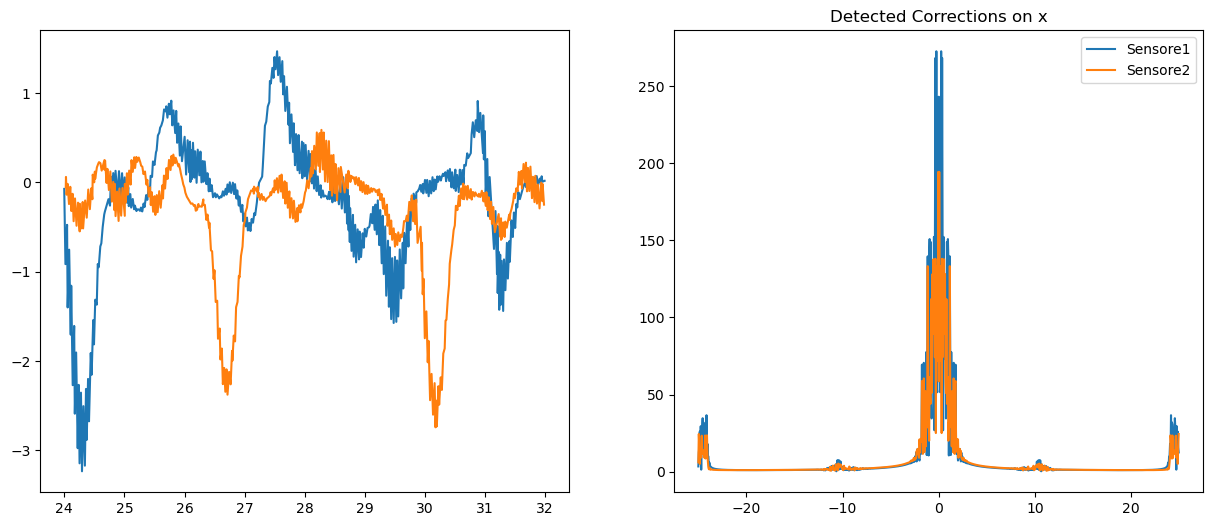

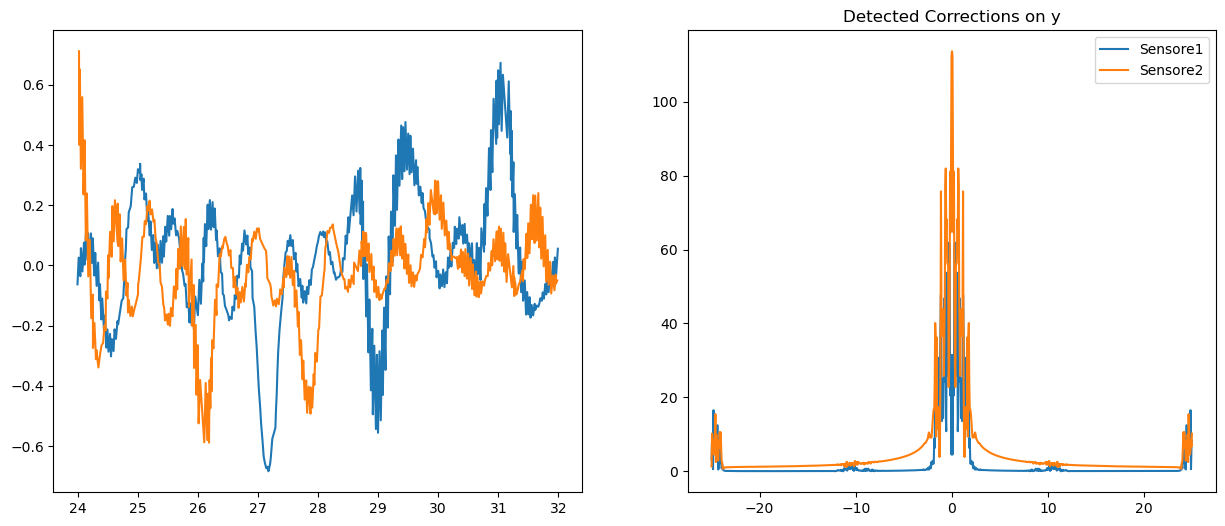

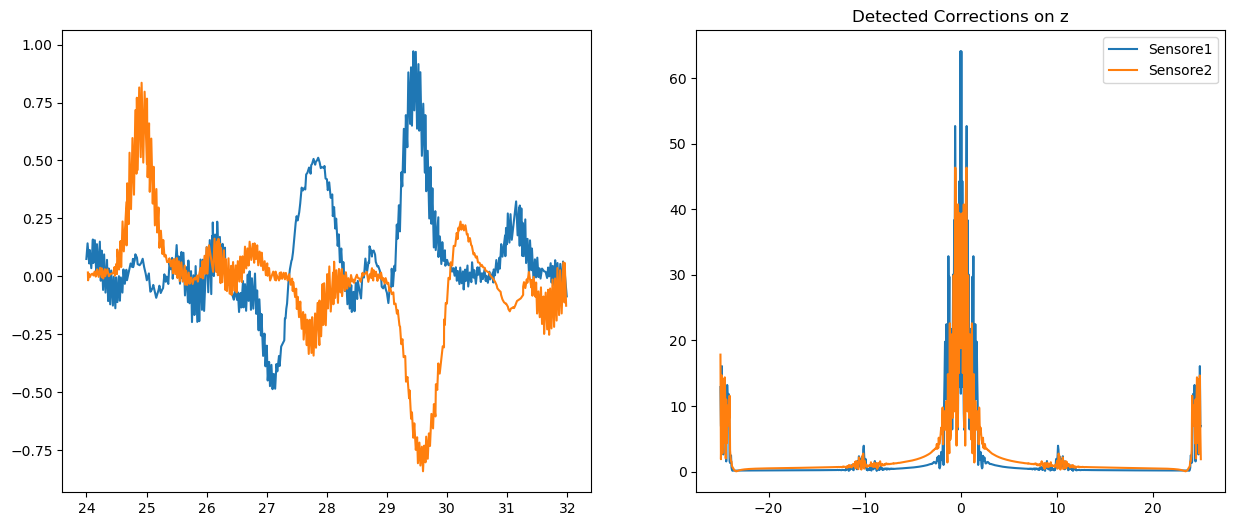

In [25]:
# @title
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(sensoreFiltrato1.time[st+zoom_st:st+zoom_end],corrz_1_x[zoom_st:zoom_end])
plt.plot(sensoreFiltrato2.time[st+zoom_st:st+zoom_end],corrz_2_x[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(sensoreFiltrato1.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_1_x))))
plt.plot(sensoreFiltrato2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_2_x))))
plt.legend(['Sensore1','Sensore2'])
plt.title('Detected Corrections on x')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(sensoreFiltrato1.time[st+zoom_st:st+zoom_end],corrz_1_y[zoom_st:zoom_end])
plt.plot(sensoreFiltrato2.time[st+zoom_st:st+zoom_end],corrz_2_y[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(sensoreFiltrato1.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_1_y))))
plt.plot(sensoreFiltrato2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_2_y))))
plt.legend(['Sensore1','Sensore2'])
plt.title('Detected Corrections on y')
plt.show()
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(sensoreFiltrato1.time[st+zoom_st:st+zoom_end],corrz_1_z[zoom_st:zoom_end])
plt.plot(sensoreFiltrato2.time[st+zoom_st:st+zoom_end],corrz_2_z[zoom_st:zoom_end])
plt.subplot(1,2,2)
plt.plot(sensoreFiltrato1.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_1_z))))
plt.plot(sensoreFiltrato2.freq_arr(dim), np.abs(np.fft.fftshift(np.fft.fft(corrz_2_z))))
plt.legend(['Sensore1','Sensore2'])
plt.title('Detected Corrections on z')
plt.show()

# Da aggiungere:
- Confronto con scarpe stessa persona, stessa velocità OK
- Confronto con altre persone stessa velocità

## Analisi correlazione caviglia/coscia

- Parte di analisi, coscia / caviglia
- Spiegazione passaggi

## correzione attiva (sguardo alla robotica)
- simulazione 3D
- correzione attiva camminata, (inevrsione correzione / anticipazione correzione)


## Prova finale
- per la ulteriore parte di analisi:
  - posso confrontare i dati con altre persone alla stessa velocità o con peso nel caso più esagerato
  - 
- per la simulazione 3D/2D posso sfruttare cpp con sfml/opengl.
  Passi da compiere:
  - Caricare dati csv su array per definire sensori
  - Gestire/costruire classe sensore come in python
  - Costruire motore fisico per simulare punti nello spazio con connesse velocità angolari e accelerazioni. 

## Scrivo i nuovi csv da mandare alla visualizzazione


1439999.0286280229
1011.7106543492881
3117803.1392355436
-291.74745676419406
-931503.5375405119
-799.2778617573172
3230177.8982587587
61.47228079079855
341628.815457162
-215.74569555536803
-1717344.266848564
66.3126627659351
1034920.2912015351
380.5566512487893
-3591093.425391815
-2155.489917339398
-1320533.0005509944
-626.5882796061065
2533480.0517514134
-857.8748802524996
-1592406.4937710278
-2207.2096673878445
777780.7375246831
1653.269437945678


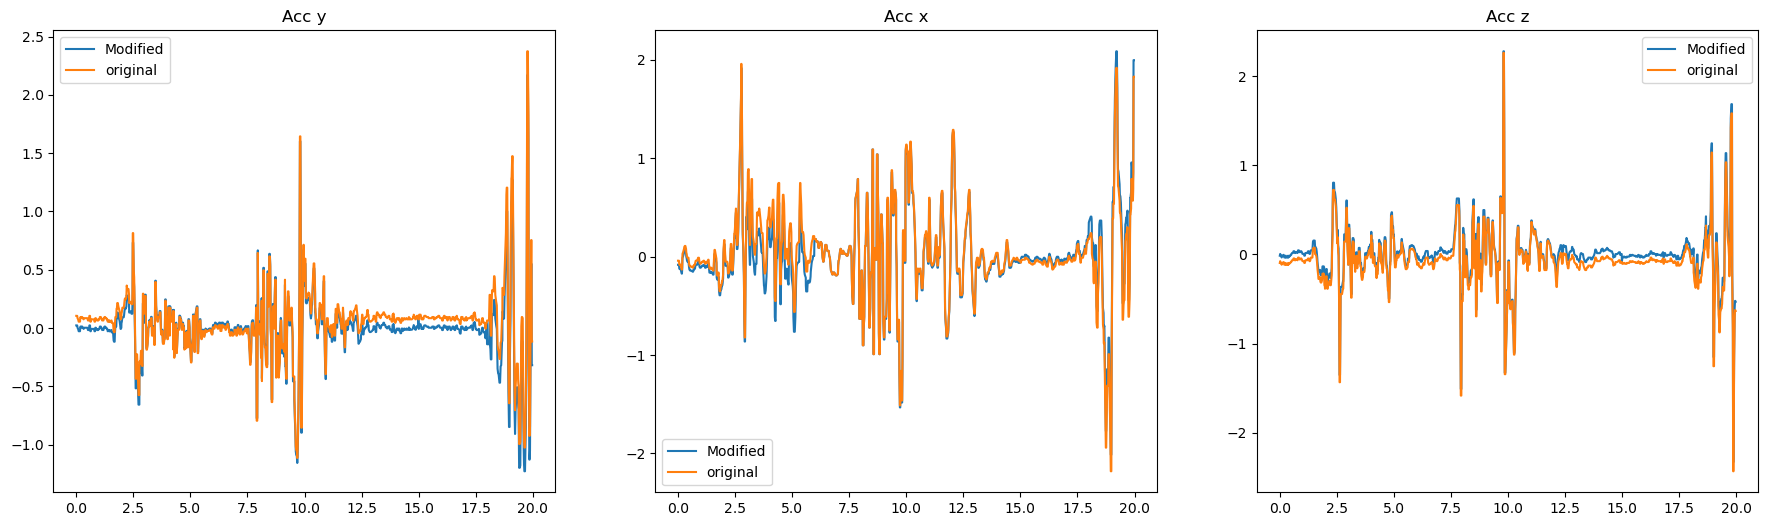

In [29]:
#fs1.save_csv("coscia_filt.csv")
#fs2.save_csv("caviglia_filt.csv")
campioni = 150

a1 = s1.ax.medfilt().normalize_3(campioni).a
a2 = s1.ay.medfilt().normalize_3(campioni).a
a3 = s1.az.medfilt().normalize_3(campioni).a
fs3 = sensor(a1,a2,a3,s1)

a1 = s2.ax.medfilt().normalize_3(campioni).a
a2 = s2.ay.medfilt().normalize_3(campioni).a
a3 = s2.az.medfilt().normalize_3(campioni).a
fs4 = sensor(a1,a2,a3,s2)

#sensore = sensor(BASEPATH + PATH_SENSORE)
s3 = sensor(BASEPATH + "Subj1/Con_scarpe/imu_2_data_sync.csv")
s4 = sensor(BASEPATH + "Subj1/Con_scarpe/imu_3_data_sync.csv")

a1 = s3.ax.medfilt().normalize_3(campioni).a
a2 = s3.ay.medfilt().normalize_3(campioni).a
a3 = s3.az.medfilt().normalize_3(campioni).a
fs5 = sensor(a1,a2,a3,s3)

a1 = s4.ax.medfilt().normalize_3(campioni).a
a2 = s4.ay.medfilt().normalize_3(campioni).a
a3 = s4.az.medfilt().normalize_3(campioni).a
fs6 = sensor(a1,a2,a3,s4)

st = 0000
end = 1000

plt.figure(figsize=(22, 6))
plt.subplot(1,3,1)
plt.plot(fs1.time[st:end],fs3.ay.a[st:end])
plt.plot(fs1.time[st:end],fs1.ay.a[st:end])
plt.legend(['Modified','original'])
plt.title('Acc y')
plt.subplot(1,3,2)
plt.plot(fs1.time[st:end],fs3.ax.a[st:end])
plt.plot(fs1.time[st:end],fs1.ax.a[st:end])
plt.legend(['Modified','original'])
plt.title('Acc x')
plt.subplot(1,3,3)
plt.plot(fs1.time[st:end],fs3.az.a[st:end])
plt.plot(fs1.time[st:end],fs1.az.a[st:end])
plt.legend(['Modified','original'])
plt.title('Acc z')
plt.show()



In [30]:
fs4.save_csv("caviglia_filtS.csv")
fs3.save_csv("coscia_filtS.csv")
fs5.save_csv("caviglia_filtD.csv")
fs6.save_csv("coscia_filtD.csv")